<a href="https://colab.research.google.com/github/priscyboatO/loan-default-prediction/blob/main/Loan_Default_Prediction_Assignment_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



Name: Priscilla Otu

Assignment 15, Loan Default Prediction


Task 1: Data Analysis and Cleaning

 Task 1.1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


Task 1.2: Upload and Load the Dataset

In [2]:
# Task 1.2 - Load the Dataset

data = pd.read_csv('bank-loan.csv')

print("Dataset loaded successfully!")
print("Dataset shape:", data.shape)

data.head()

Dataset loaded successfully!
Dataset shape: (850, 9)


,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0


Task 1.3: Examine the Dataset

In [3]:
print("Dataset Information:")
data.info()

print("\nSummary Statistics:")
display(data.describe())

print("\nMissing Values:")
print(data.isnull().sum())

print("\nTarget Distribution:")
print(data['default'].value_counts(dropna=False))

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    int64  
 1   ed        850 non-null    int64  
 2   employ    850 non-null    int64  
 3   address   850 non-null    int64  
 4   income    850 non-null    int64  
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   default   700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 59.9 KB

Summary Statistics:


,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
count,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,700.000000
mean,35.029412,1.710588,8.565882,8.371765,46.675294,10.171647,1.576805,3.078789,0.261429
std,8.041432,0.927784,6.777884,6.895016,38.543054,6.719441,2.125840,3.398803,0.439727
min,20.000000,1.000000,0.000000,0.000000,13.000000,0.100000,0.011696,0.045584,0.000000
25%,29.000000,1.000000,3.000000,3.000000,24.000000,5.100000,0.382176,1.045942,0.000000
50%,34.000000,1.000000,7.000000,7.000000,35.000000,8.700000,0.885091,2.003243,0.000000
75%,41.000000,2.000000,13.000000,12.000000,55.750000,13.800000,1.898440,3.903001,1.000000
max,56.000000,5.000000,33.000000,34.000000,446.000000,41.300000,20.561310,35.197500,1.000000



Missing Values:
age           0
ed            0
employ        0
address       0
income        0
debtinc       0
creddebt      0
othdebt       0
default     150
dtype: int64

Target Distribution:
default
0.0    517
1.0    183
NaN    150
Name: count, dtype: int64


Task 1.4: Exploratory Data Analysis

The following visualizations show the distribution of loan default and the relationship between debt-to-income ratio and default status.

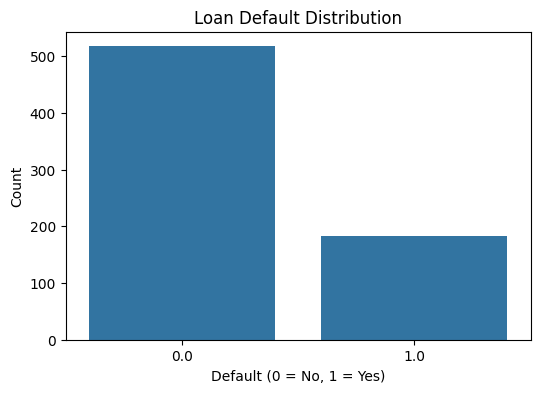

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='default', data=data)
plt.title('Loan Default Distribution')
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

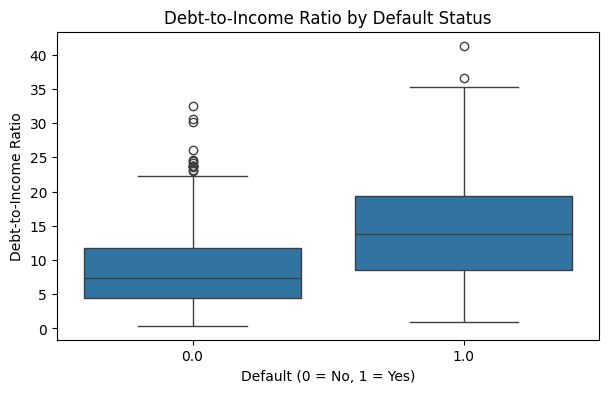

In [5]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='default', y='debtinc', data=data)
plt.title('Debt-to-Income Ratio by Default Status')
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.ylabel('Debt-to-Income Ratio')
plt.show()

Task 1.5: Clean the Dataset

The default column contains missing target values. Because the true outcome is unknown for those records, the missing target rows are removed rather than imputed.

In [7]:
data_clean = data.dropna(subset=['default']).copy()
data_clean['default'] = data_clean['default'].astype(int)

print("Original rows:", len(data))
print("Rows after removing missing target values:", len(data_clean))
print("\nMissing values after cleaning:")
print(data_clean.isnull().sum())

Original rows: 850
Rows after removing missing target values: 700

Missing values after cleaning:
age         0
ed          0
employ      0
address     0
income      0
debtinc     0
creddebt    0
othdebt     0
default     0
dtype: int64


Task 2: Feature Engineering

Task 2.1: Create New Features

Three additional features are created:

- TotalDebt: total credit and other debt.
- CreditDebtRatio: proportion of total debt represented by credit debt.
- IncomePerEmploymentYear: income relative to years of employment.

In [8]:
data_clean['TotalDebt'] = data_clean['creddebt'] + data_clean['othdebt']

data_clean['CreditDebtRatio'] = (
    data_clean['creddebt'] / (data_clean['TotalDebt'] + 1e-6)
)

data_clean['IncomePerEmploymentYear'] = (
    data_clean['income'] / (data_clean['employ'] + 1)
)

display(data_clean.head())

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default,TotalDebt,CreditDebtRatio,IncomePerEmploymentYear
0,41,3,17,12,176,9.3,11.359392,5.008608,1,16.368,0.694,9.777778
1,27,1,10,6,31,17.3,1.362202,4.000798,0,5.363,0.254,2.818182
2,40,1,15,14,55,5.5,0.856075,2.168925,0,3.025,0.283,3.437500
3,41,1,15,14,120,2.9,2.658720,0.821280,0,3.480,0.764,7.500000
4,24,2,2,0,28,17.3,1.787436,3.056564,1,4.844,0.369,9.333333


Task 2.2: Define Features, Target and Fairness Group

Age is retained for model training and is also used to create demographic groups for fairness evaluation.

In [9]:
X = data_clean.drop(columns=['default'])
y = data_clean['default']

age_groups = pd.cut(
    data_clean['age'],
    bins=[0, 29, 39, np.inf],
    labels=['Under 30', '30-39', '40+']
)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nAge group distribution:")
print(age_groups.value_counts())

Feature shape: (700, 11)
Target shape: (700,)

Age group distribution:
age
30-39       281
Under 30    218
40+         201
Name: count, dtype: int64


 Task 2.3: Split and Scale the Data

In [10]:
X_train, X_test, y_train, y_test, age_train, age_test = train_test_split(
    X,
    y,
    age_groups,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = MinMaxScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (560, 11)
Testing data shape: (140, 11)


Task 3: Model Building and Evaluation

Task 3.1: Train the Random Forest Model

In [11]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


Task 3.2: Evaluate Model Performance

In [12]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8000

Confusion Matrix:
[[92 11]
 [17 20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       103
           1       0.65      0.54      0.59        37

    accuracy                           0.80       140
   macro avg       0.74      0.72      0.73       140
weighted avg       0.79      0.80      0.79       140



Task 3.3: Confusion Matrix Visualization

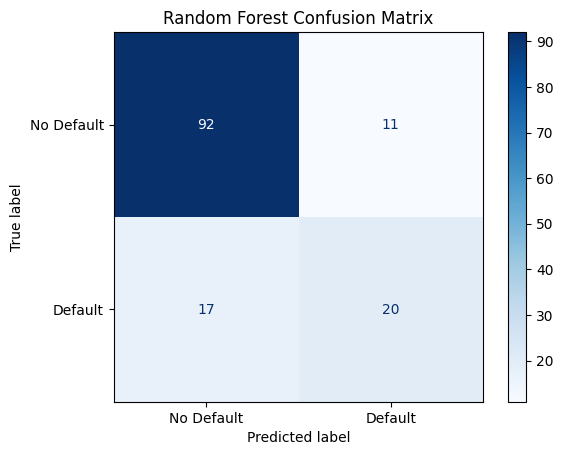

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['No Default', 'Default'],
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')
plt.show()

Task 3.4: Feature Importance

Feature importance shows which variables contributed most to the Random Forest model's predictions.

,Feature,Importance
5,debtinc,0.135649
10,IncomePerEmploymentYear,0.123538
2,employ,0.115531
6,creddebt,0.110208
8,TotalDebt,0.085719
0,age,0.084895
9,CreditDebtRatio,0.084500
7,othdebt,0.083869
3,address,0.077817
4,income,0.075633


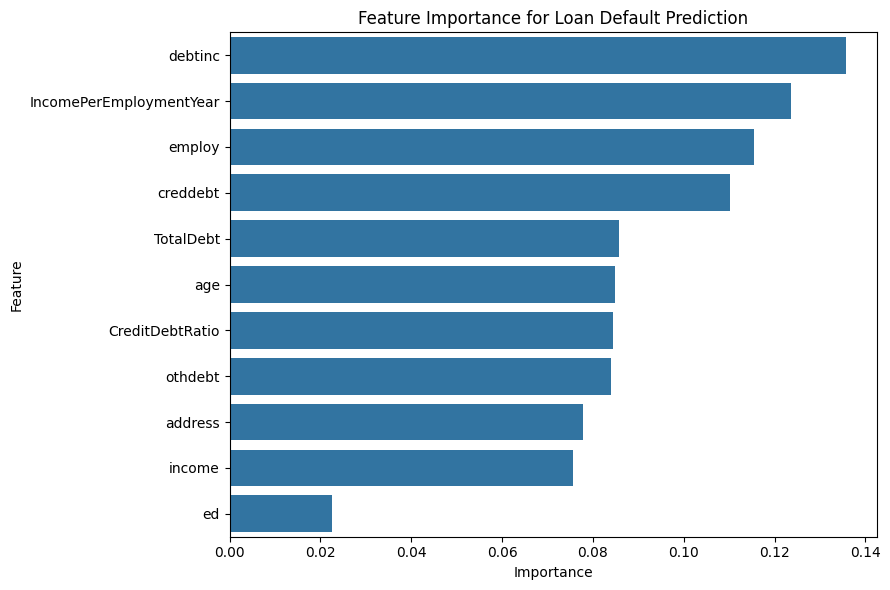

In [14]:
feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

display(feature_importance)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)
plt.title('Feature Importance for Loan Default Prediction')
plt.tight_layout()
plt.show()

 Task 4: Explainability and Fairness Analysis

Task 4.1: Install and Import SHAP

In [15]:
!pip install -q shap

In [16]:
import shap
print("SHAP imported successfully!")

SHAP imported successfully!


 Task 4.2: SHAP Global Explainability

The SHAP summary plot shows which features have the strongest overall influence on loan-default predictions and the direction of their effects.

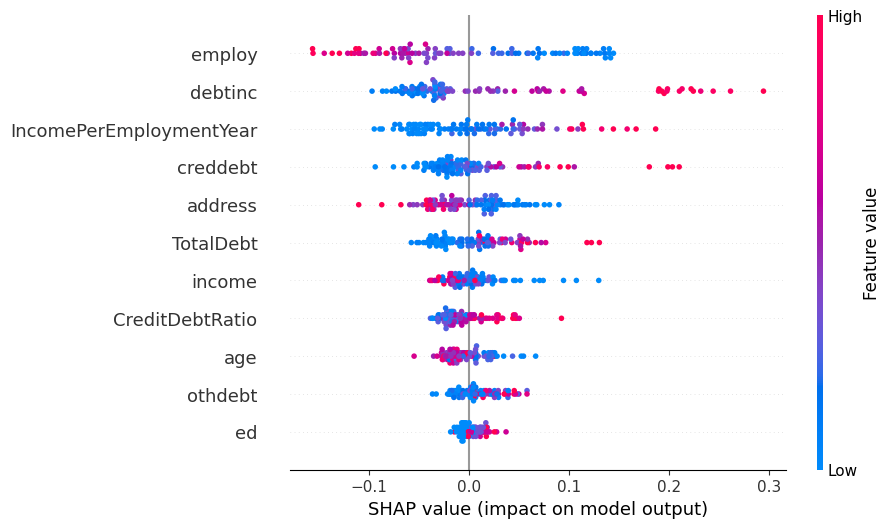

In [17]:
X_shap = X_test_scaled.iloc[:100].copy()

explainer = shap.TreeExplainer(model)
shap_result = explainer(X_shap)

# Random Forest SHAP output may include a class dimension.
if len(shap_result.values.shape) == 3:
    shap_default = shap.Explanation(
        values=shap_result.values[:, :, 1],
        base_values=shap_result.base_values[:, 1],
        data=shap_result.data,
        feature_names=list(X_shap.columns)
    )
else:
    shap_default = shap_result

shap.plots.beeswarm(shap_default, max_display=12)

Task 4.3: Fairness Analysis Across Age Groups

The dataset does not contain gender, so age groups are used as the demographic attribute for fairness analysis. Accuracy, precision, recall, and positive prediction rate are compared across groups.

In [19]:
from sklearn.metrics import precision_score, recall_score

fairness_results = []

for group in age_test.cat.categories:
    mask = (age_test == group)

    group_true = y_test.loc[mask]
    group_pred = pd.Series(y_pred, index=y_test.index).loc[mask]

    fairness_results.append({
        'Age Group': str(group),
        'Count': int(mask.sum()),
        'Accuracy': accuracy_score(group_true, group_pred),
        'Precision': precision_score(group_true, group_pred, zero_division=0),
        'Recall': recall_score(group_true, group_pred, zero_division=0),
        'Positive Prediction Rate': group_pred.mean()
    })

fairness_df = pd.DataFrame(fairness_results)

print("Fairness Metrics by Age Group:")
display(fairness_df)

Fairness Metrics by Age Group:


,Age Group,Count,Accuracy,Precision,Recall,Positive Prediction Rate
0,Under 30,40,0.700000,0.666667,0.500000,0.300000
1,30-39,62,0.854839,0.615385,0.666667,0.209677
2,40+,38,0.815789,0.666667,0.444444,0.157895


Task 4.4: Fairness Metrics Visualization

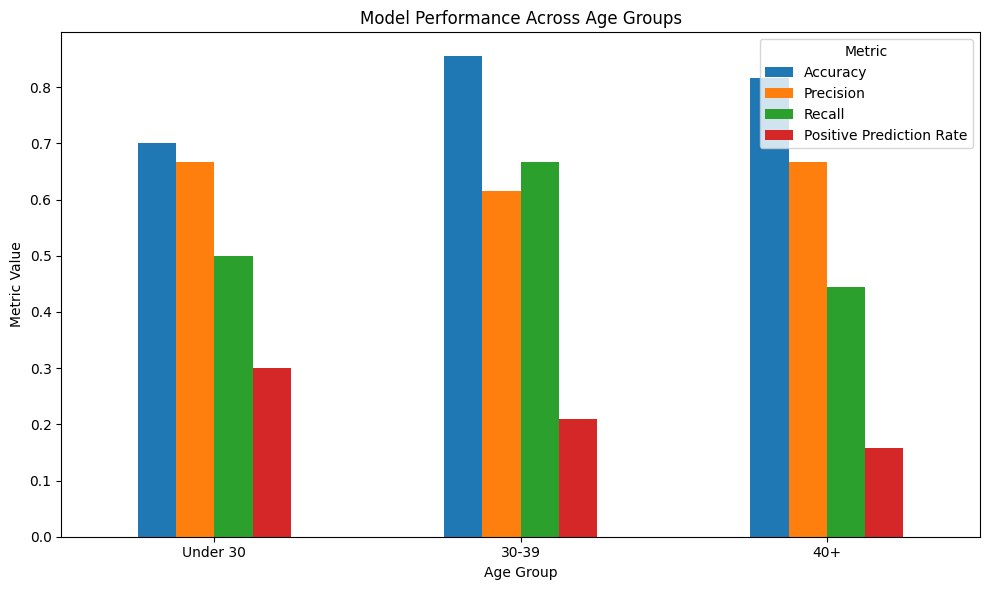

In [20]:
fairness_plot = fairness_df.set_index('Age Group')[
    ['Accuracy', 'Precision', 'Recall', 'Positive Prediction Rate']
]

fairness_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Model Performance Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Metric Value')
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

Task 4.6: Fairness Interpretation

Differences in accuracy, precision, recall, or positive prediction rates across age groups may indicate that the model performs differently for different demographic groups. These differences should be investigated before using the model for real lending decisions. Fairness can be improved by collecting representative data, testing additional fairness metrics, reviewing influential features, and applying fairness-aware mitigation methods where appropriate.

Task 5: Ethical Considerations

Fairness:

The model should not unfairly disadvantage borrowers because of demographic characteristics. Performance should be evaluated across relevant groups, and significant disparities should be investigated before deployment. Age was used in this project to examine whether model performance differs across demographic groups.

Privacy:

Loan datasets may contain sensitive financial and personal information. Data should be anonymized, securely stored, encrypted where appropriate, and accessed only by authorized users. Only information necessary for the prediction task should be collected and retained.

Transparency and Explainability:

Borrowers and decision-makers should be able to understand the main factors influencing model predictions. Feature importance and SHAP explanations improve transparency by showing how features contribute to predictions. Automated predictions should support, rather than completely replace, appropriate human review in high-impact lending decisions.

Recommendations for Reducing Bias:

Potential improvements include using more representative training data, examining group-level error rates regularly, removing or carefully reviewing sensitive and proxy variables, comparing multiple models, applying fairness-aware mitigation techniques when needed, and monitoring the model after deployment for changes in performance or fairness.